# Signal Combination Analysis

Tests whether combining A6 shallowing + A5 condensation into a composite score improves ICIR over any single signal, and whether an OBI gate on top of the composite further improves it.

**Three questions:**
1. Are A5 and A6 correlated? (If yes, combining them adds little)
2. Does the composite ICIR beat the best individual signal?
3. Does filtering on OBI agreement improve the composite IC?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

PROJECT_ROOT = Path("/Users/krishhiv/Desktop/argus-alpha-research")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from research.data.load_data import load_depth, DATA_ROOT
from research.features.depth_features import add_all_features

HORIZONS    = [5, 10, 20, 50]
CORE_SIGS   = ["a6_ask_shallowing", "a6_bid_shallowing", "a5_condensation_signal", "obi"]
COMPOSITES  = ["composite_eq", "composite_obi_gate"]

print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")

DATA_ROOT exists: True


## Section 1 — Load Data (with previous-day calibration)

In [2]:
# Inventory
all_parquets = sorted(DATA_ROOT.glob("trading_date=*/symbol=*/compacted-*.parquet"))
records = []
for p in all_parquets:
    date_str    = p.parent.parent.name.split("=")[1]
    symbol_full = p.parent.name.split("=")[1]
    underlying  = symbol_full.split("-")[0]
    if underlying.startswith("BAJFINANCE"):
        continue
    records.append({"date": date_str, "underlying": underlying, "path": p})

inventory = pd.DataFrame(records)
print(f"Files: {len(inventory)}")
print(inventory.groupby("underlying")["date"].count().rename("days"))

Files: 79
underlying
HDFCBANK     20
ICICIBANK    20
RELIANCE     20
TCS          19
Name: days, dtype: int64


In [3]:
# Previous-day calibration (same approach as ic_analysis.ipynb)
print("Building calibration lookup...")
calib = {}
for _, row in inventory.iterrows():
    try:
        df_c = pd.read_parquet(row["path"], columns=["bid_qty_01"])
        calib[(row["underlying"], row["date"])] = float(df_c["bid_qty_01"].median())
    except Exception as e:
        print(f"  Calib error {row['underlying']} {row['date']}: {e}")

prev_calib = {}
for underlying in inventory["underlying"].unique():
    dates = sorted(inventory[inventory["underlying"] == underlying]["date"].unique())
    for i, date in enumerate(dates):
        prev_calib[(underlying, date)] = calib.get((underlying, dates[i - 1])) if i > 0 else None

available = sum(1 for v in prev_calib.values() if v is not None)
print(f"Pairs with previous-day calibration: {available}/{len(prev_calib)}")

Building calibration lookup...
Pairs with previous-day calibration: 75/79


In [4]:
all_dfs = []
skipped = 0

for _, row in inventory.iterrows():
    key     = (row["underlying"], row["date"])
    p_calib = prev_calib.get(key)

    if p_calib is None:
        skipped += 1
        continue

    try:
        df = load_depth(row["underlying"], row["date"], session_filter=True, path=row["path"])
        df = add_all_features(df, size_threshold=p_calib, order_size=p_calib * 10)

        for h in HORIZONS:
            df[f"fwd_ret_{h}"] = df["midprice"].shift(-h) / df["midprice"] - 1

        df["date"]       = row["date"]
        df["underlying"] = row["underlying"]
        all_dfs.append(df)
        print(f"  {row['underlying']} {row['date']} ... {len(df):,} rows")

    except FileNotFoundError:
        print(f"  SKIP {row['underlying']} {row['date']}: file not found")
    except ValueError as e:
        print(f"  SKIP {row['underlying']} {row['date']}: {e}")
    except Exception as e:
        print(f"  ERROR {row['underlying']} {row['date']}: {e}")

print(f"\nLoaded {len(all_dfs)} files ({skipped} skipped — first day per instrument)")
print(f"Total rows: {sum(len(d) for d in all_dfs):,}")

  HDFCBANK 2026-04-27 ... 92,996 rows
  ICICIBANK 2026-04-27 ... 93,247 rows
  RELIANCE 2026-04-27 ... 92,985 rows
  TCS 2026-04-27 ... 91,942 rows
  HDFCBANK 2026-04-28 ... 91,761 rows
  ICICIBANK 2026-04-28 ... 91,952 rows
  RELIANCE 2026-04-28 ... 91,951 rows
  TCS 2026-04-28 ... 91,897 rows
  HDFCBANK 2026-04-29 ... 91,834 rows
  ICICIBANK 2026-04-29 ... 91,642 rows
  RELIANCE 2026-04-29 ... 91,982 rows
  TCS 2026-04-29 ... 92,041 rows
  HDFCBANK 2026-04-30 ... 94,626 rows
  ICICIBANK 2026-04-30 ... 95,200 rows
  RELIANCE 2026-04-30 ... 95,001 rows
  TCS 2026-04-30 ... 94,459 rows
  HDFCBANK 2026-05-04 ... 101,341 rows
  ICICIBANK 2026-05-04 ... 101,829 rows
  RELIANCE 2026-05-04 ... 100,912 rows
  TCS 2026-05-04 ... 100,297 rows
  HDFCBANK 2026-05-05 ... 93,700 rows
  ICICIBANK 2026-05-05 ... 92,825 rows
  RELIANCE 2026-05-05 ... 93,581 rows
  TCS 2026-05-05 ... 93,467 rows
  HDFCBANK 2026-05-06 ... 91,967 rows
  ICICIBANK 2026-05-06 ... 91,832 rows
  RELIANCE 2026-05-06 ... 92,01

## Section 2 — Signal Correlation

Are A5 and A6 measuring different things? If correlation > 0.7, combining them adds little new information.

In [5]:
# Pool a random sample across all days for correlation (full dataset is ~5.6M rows)
sample_dfs = []
for df in all_dfs:
    cols = [c for c in CORE_SIGS if c in df.columns]
    sample_dfs.append(df[cols].dropna().sample(min(5_000, len(df)), random_state=42))

pool = pd.concat(sample_dfs, ignore_index=True)
print(f"Pooled sample: {len(pool):,} rows")

# Spearman rank correlation (consistent with how IC is measured)
corr = pool.corr(method="spearman")
print("\nSpearman correlation matrix:")
print(corr.round(3))

Pooled sample: 370,000 rows

Spearman correlation matrix:
                        a6_ask_shallowing  a6_bid_shallowing  \
a6_ask_shallowing                   1.000             -0.044   
a6_bid_shallowing                  -0.044              1.000   
a5_condensation_signal              0.347             -0.349   
obi                                 0.082             -0.086   

                        a5_condensation_signal    obi  
a6_ask_shallowing                        0.347  0.082  
a6_bid_shallowing                       -0.349 -0.086  
a5_condensation_signal                   1.000  0.122  
obi                                      0.122  1.000  


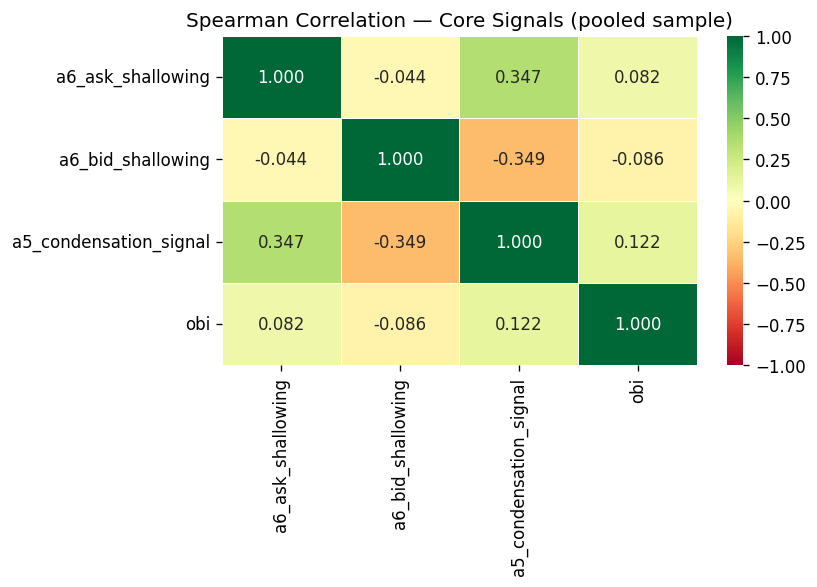

In [6]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
sns.heatmap(
    corr, annot=True, fmt=".3f", center=0,
    cmap="RdYlGn", linewidths=0.5, ax=ax,
    vmin=-1, vmax=1,
)
ax.set_title("Spearman Correlation — Core Signals (pooled sample)", fontsize=12)
plt.tight_layout()
plt.show()

## Section 3 — Build Composite Score

Each signal is z-scored with a rolling window before combining so that differences in raw scale do not give one signal disproportionate weight in the composite.

**Composite (equal weight):**
```
composite_eq = zscore(a6_ask_shallowing) - zscore(a6_bid_shallowing) + zscore(a5_condensation_signal)
```

The A6 bid signal is subtracted because its raw IC is negative — bid shallowing is bearish.

In [7]:
ZSCORE_WINDOW = 100  # packets — ~30-50 seconds of history

def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    mu  = series.rolling(window, min_periods=20).mean()
    std = series.rolling(window, min_periods=20).std()
    return (series - mu) / (std + 1e-9)

for df in all_dfs:
    z_ask = rolling_zscore(df["a6_ask_shallowing"],      ZSCORE_WINDOW)
    z_bid = rolling_zscore(df["a6_bid_shallowing"],      ZSCORE_WINDOW)
    z_a5  = rolling_zscore(df["a5_condensation_signal"], ZSCORE_WINDOW)

    # Equal-weight composite: A6 pair + A5
    df["composite_eq"] = z_ask - z_bid + z_a5

print("Composite scores added to all DataFrames.")
print(f"Sample stats (first file):")
print(all_dfs[0][["composite_eq"]].describe().round(4))

Composite scores added to all DataFrames.
Sample stats (first file):
       composite_eq
count    92957.0000
mean         0.0031
std          2.2464
min        -14.8808
25%         -1.4700
50%         -0.0033
75%          1.4700
max         12.2193


## Section 4 — IC Comparison: Composite vs Individual Signals

Does combining signals improve ICIR over the best individual signal alone?

In [8]:
signals_to_compare = [
    "a6_ask_shallowing",
    "a6_bid_shallowing",
    "a5_condensation_signal",
    "obi",
    "composite_eq",
]

ic_records = []
for df in all_dfs:
    date       = df["date"].iloc[0]
    underlying = df["underlying"].iloc[0]

    for sig in signals_to_compare:
        if sig not in df.columns:
            continue
        for h in HORIZONS:
            fwd_col = f"fwd_ret_{h}"
            valid   = df[[sig, fwd_col]].dropna()
            if len(valid) < 50:
                continue
            ic, pval = spearmanr(valid[sig], valid[fwd_col])
            ic_records.append({
                "date": date, "underlying": underlying,
                "signal": sig, "horizon": h, "ic": ic,
            })

ic_df = pd.DataFrame(ic_records)
print(f"IC records: {len(ic_df)}")

/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/2760793536.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, pval = spearmanr(valid[sig], valid[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/2760793536.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, pval = spearmanr(valid[sig], valid[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/2760793536.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, pval = spearmanr(valid[sig], valid[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/2760793536.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, pval = spearmanr(valid[sig], valid[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/2760793536.py:22: Const

IC records: 1480


In [9]:
summary = (
    ic_df
    .groupby(["signal", "horizon"])["ic"]
    .agg(mean_ic="mean", std_ic="std", count="count")
    .reset_index()
)
summary["icir"]    = summary["mean_ic"] / (summary["std_ic"] + 1e-9)
summary["pct_pos"] = (
    ic_df.groupby(["signal", "horizon"])["ic"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(drop=True)
)

print("=" * 80)
print("IC COMPARISON — Individual signals vs Composite")
print("=" * 80)

for h in HORIZONS:
    sub = summary[summary["horizon"] == h].copy()
    sub = sub.sort_values("mean_ic", key=lambda s: s.abs(), ascending=False)
    print(f"\n--- Horizon = {h} packets ---")
    print(f"{'signal':<28} {'mean_ic':>9} {'std_ic':>9} {'icir':>9} {'pct_pos':>9}")
    print("-" * 68)
    for _, r in sub.iterrows():
        marker = "  <<< COMPOSITE" if r["signal"] == "composite_eq" else ""
        print(f"{r['signal']:<28} {r['mean_ic']:>9.4f} {r['std_ic']:>9.4f} {r['icir']:>9.4f} {r['pct_pos']:>9.4f}{marker}")

IC COMPARISON — Individual signals vs Composite

--- Horizon = 5 packets ---
signal                         mean_ic    std_ic      icir   pct_pos
--------------------------------------------------------------------
composite_eq                    0.0674    0.0208    3.2361    0.9865  <<< COMPOSITE
a6_bid_shallowing              -0.0626    0.0190   -3.2996    0.0000
a6_ask_shallowing               0.0560    0.0177    3.1604    0.9865
a5_condensation_signal          0.0500    0.0217    2.3061    0.9730
obi                             0.0205    0.0206    0.9964    0.8108

--- Horizon = 10 packets ---
signal                         mean_ic    std_ic      icir   pct_pos
--------------------------------------------------------------------
composite_eq                    0.0707    0.0236    3.0011    0.9865  <<< COMPOSITE
a6_bid_shallowing              -0.0676    0.0216   -3.1352    0.0000
a6_ask_shallowing               0.0613    0.0203    3.0140    0.9865
a5_condensation_signal          0.0

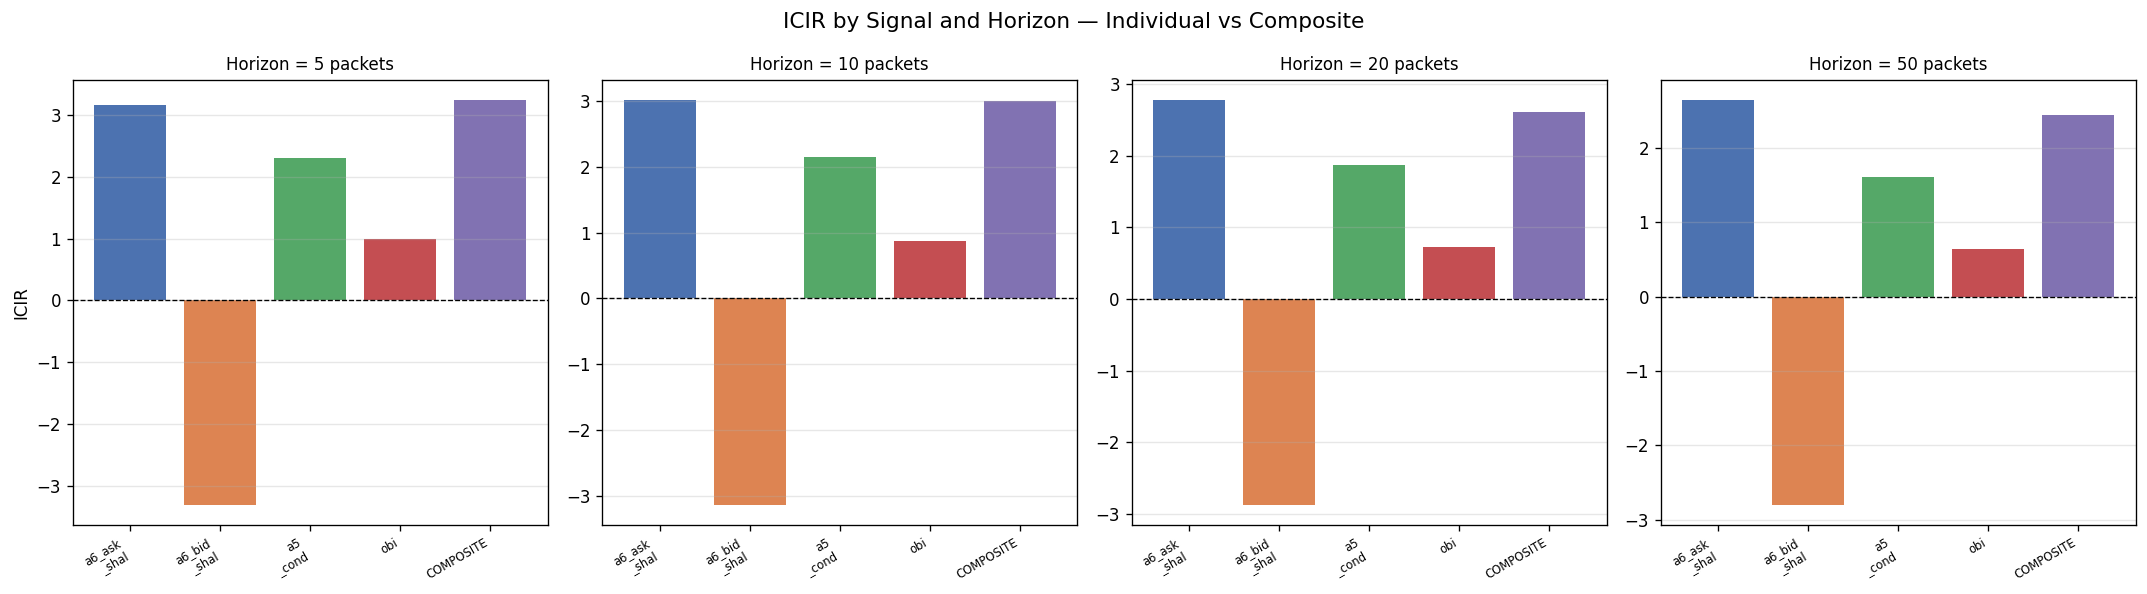

In [10]:
# Bar chart: ICIR by signal at each horizon
pivot_icir = summary.pivot(index="signal", columns="horizon", values="icir")
pivot_icir = pivot_icir.loc[signals_to_compare]   # consistent row order

fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=120, sharey=False)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for idx, h in enumerate(HORIZONS):
    ax   = axes[idx]
    vals = pivot_icir[h]
    bars = ax.bar(range(len(vals)), vals.values, color=colors)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(
        [s.replace("_shallowing","\n_shal").replace("_condensation_signal","\n_cond").replace("composite_eq","COMPOSITE") for s in vals.index],
        fontsize=7, rotation=30, ha="right"
    )
    ax.set_title(f"Horizon = {h} packets", fontsize=10)
    ax.set_ylabel("ICIR" if idx == 0 else "")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("ICIR by Signal and Horizon — Individual vs Composite", fontsize=13)
plt.tight_layout()
plt.show()

## Section 5 — OBI Gate Analysis

Does filtering to only rows where OBI agrees with the composite direction improve IC?

- **Gated rows:** composite > 0 and obi > 0, OR composite < 0 and obi < 0
- **Ungated rows:** all rows

If IC is higher on gated rows, the OBI gate adds value as an entry filter.

In [11]:
gate_records = []

for df in all_dfs:
    date       = df["date"].iloc[0]
    underlying = df["underlying"].iloc[0]

    if "composite_eq" not in df.columns or "obi" not in df.columns:
        continue

    # OBI agrees with composite direction
    obi_gate = np.sign(df["composite_eq"]) == np.sign(df["obi"])

    for h in HORIZONS:
        fwd_col = f"fwd_ret_{h}"

        # Ungated
        valid_all = df[["composite_eq", fwd_col]].dropna()
        if len(valid_all) >= 50:
            ic_all, _ = spearmanr(valid_all["composite_eq"], valid_all[fwd_col])
            gate_records.append({"date": date, "underlying": underlying,
                                  "horizon": h, "gate": "ungated", "ic": ic_all,
                                  "n": len(valid_all)})

        # OBI-gated
        gated = df[obi_gate][["composite_eq", fwd_col]].dropna()
        if len(gated) >= 50:
            ic_gated, _ = spearmanr(gated["composite_eq"], gated[fwd_col])
            gate_records.append({"date": date, "underlying": underlying,
                                  "horizon": h, "gate": "obi_gated", "ic": ic_gated,
                                  "n": len(gated)})

gate_df = pd.DataFrame(gate_records)

gate_summary = (
    gate_df
    .groupby(["gate", "horizon"])["ic"]
    .agg(mean_ic="mean", std_ic="std")
    .reset_index()
)
gate_summary["icir"] = gate_summary["mean_ic"] / (gate_summary["std_ic"] + 1e-9)

# Average rows kept by OBI gate
rows_kept = gate_df.groupby(["gate", "horizon"])["n"].mean()

print("OBI Gate IC Summary:")
print(gate_summary.to_string(index=False))
print("\nMean rows per day×symbol:")
print(rows_kept)

/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/3745726204.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_all, _ = spearmanr(valid_all["composite_eq"], valid_all[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/3745726204.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_gated, _ = spearmanr(gated["composite_eq"], gated[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/3745726204.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_all, _ = spearmanr(valid_all["composite_eq"], valid_all[fwd_col])
/var/folders/v4/87c4fhgs3p1963d73j6s71m00000gn/T/ipykernel_24052/3745726204.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic_gated, _ = spearmanr(gated["composite_eq"], gated[fwd_col])
/var/folders/v4/87c4

OBI Gate IC Summary:
     gate  horizon  mean_ic   std_ic     icir
obi_gated        5 0.069079 0.025718 2.686063
obi_gated       10 0.072626 0.030558 2.376645
obi_gated       20 0.070711 0.034764 2.034033
obi_gated       50 0.059036 0.034964 1.688472
  ungated        5 0.067393 0.020825 3.236114
  ungated       10 0.070693 0.023556 3.001090
  ungated       20 0.069507 0.026653 2.607851
  ungated       50 0.055353 0.022636 2.445400

Mean rows per day×symbol:
gate       horizon
obi_gated  5          48913.310811
           10         48910.513514
           20         48905.310811
           50         48890.189189
ungated    5          93757.797297
           10         93752.797297
           20         93742.797297
           50         93712.797297
Name: n, dtype: float64


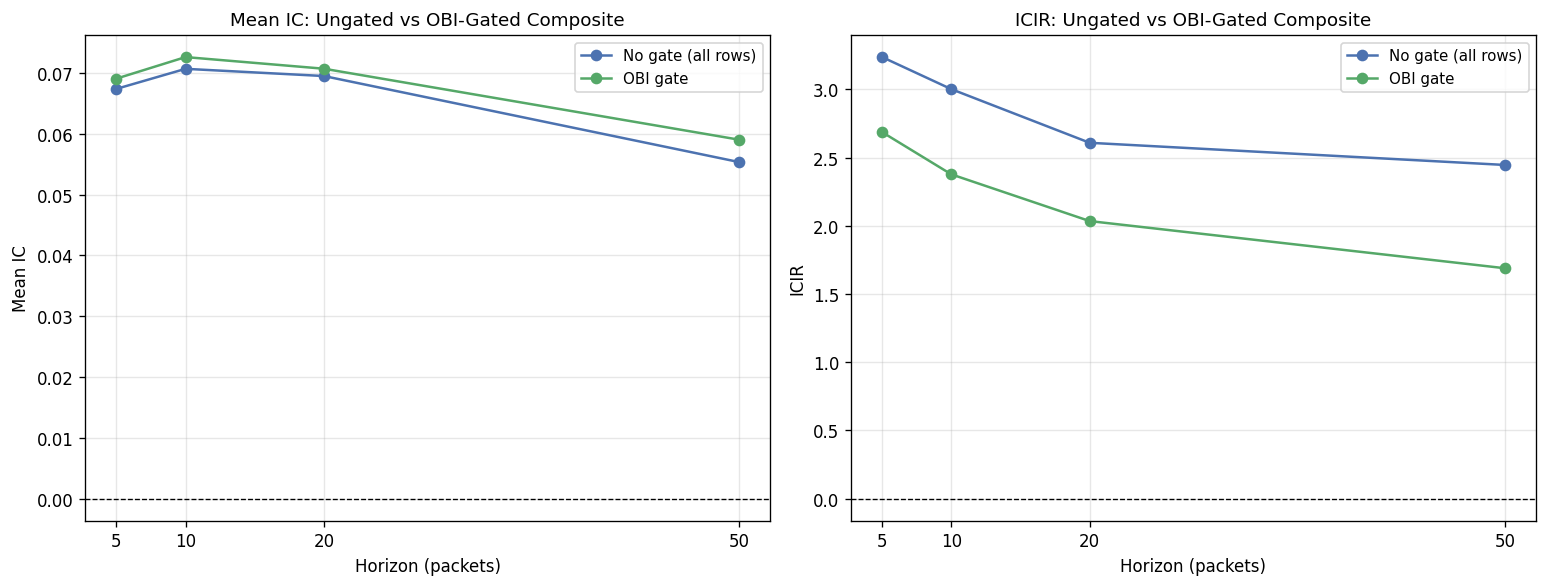


OBI gate retains 52.2% of rows on average


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

for gate, color, label in [
    ("ungated",  "#4C72B0", "No gate (all rows)"),
    ("obi_gated","#55A868", "OBI gate"),
]:
    sub = gate_summary[gate_summary["gate"] == gate].sort_values("horizon")
    axes[0].plot(sub["horizon"], sub["mean_ic"], marker="o", label=label, color=color)
    axes[1].plot(sub["horizon"], sub["icir"],    marker="o", label=label, color=color)

for ax, ylabel, title in [
    (axes[0], "Mean IC",  "Mean IC: Ungated vs OBI-Gated Composite"),
    (axes[1], "ICIR",     "ICIR: Ungated vs OBI-Gated Composite"),
]:
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Horizon (packets)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# What fraction of rows does the OBI gate keep?
n_ungated = gate_df[gate_df["gate"] == "ungated"]["n"].mean()
n_gated   = gate_df[gate_df["gate"] == "obi_gated"]["n"].mean()
print(f"\nOBI gate retains {n_gated / n_ungated * 100:.1f}% of rows on average")

---
## Summary

**Read these outputs in order:**

1. **Correlation matrix** — if A5 and A6 are < 0.5 correlated, the composite is adding genuinely new information.

2. **IC comparison table** — if `composite_eq` ICIR > best individual signal ICIR (~3.16), the blend is worth using. If not, use A6 alone.

3. **OBI gate** — if mean IC and ICIR are materially higher on gated rows AND the gate retains > 50% of rows, use Blend 2 (composite + OBI gate). If improvement is marginal or row count drops too much, use Blend 1 (composite only).